<a href="https://colab.research.google.com/github/orange231201/Data-mining-policy-summary-/blob/main/CNN_Depth_MNIST_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Check TensorFlow version
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score

In [ ]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


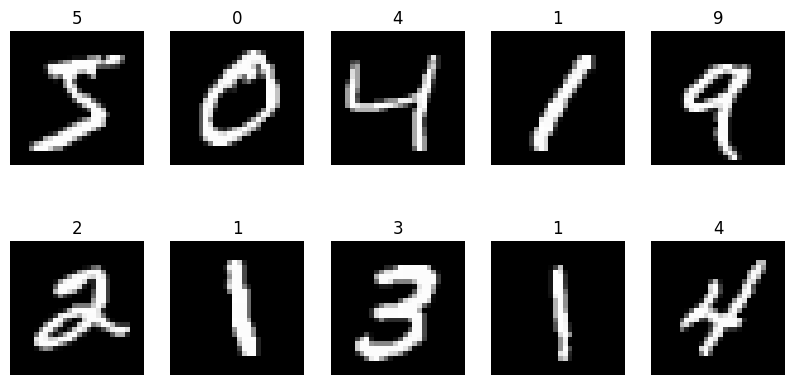

In [ ]:
# Visualise sample handwritten digit images
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [ ]:
# Normalise image pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
# Reshape images for CNN input
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
# Convert labels to one-hot encoded format
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(y_train.shape)

(60000, 10)


In [ ]:
# Create CNN model with one convolutional layer
model_1 = Sequential()

model_1.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model_1.add(MaxPooling2D((2,2)))

model_1.add(Flatten())

model_1.add(Dense(128, activation='relu'))

model_1.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Display CNN1 architecture
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081,888 (7.94 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,387,926 (5.29 MB)

In [ ]:
# Compile CNN1 model
model_1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train CNN1 model
history_1 = model_1.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9286 - loss: 0.2551 - val_accuracy: 0.9728 - val_loss: 0.1000
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9775 - loss: 0.0777 - val_accuracy: 0.9790 - val_loss: 0.0730
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.9855 - loss: 0.0503 - val_accuracy: 0.9810 - val_loss: 0.0661
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9890 - loss: 0.0372 - val_accuracy: 0.9841 - val_loss: 0.0533
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9915 - loss: 0.0280 - val_accuracy: 0.9843 - val_loss: 0.0524


In [ ]:
# Evaluate CNN1 performance
loss_1, acc_1 = model_1.evaluate(
    X_test,
    y_test
)

print("CNN Model 1 Accuracy:", acc_1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9854 - loss: 0.0454
CNN Model 1 Accuracy: 0.9854000210762024


In [ ]:
# Create CNN model with two convolutional layers
model_2 = Sequential()

model_2.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model_2.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model_2.add(MaxPooling2D((2,2)))

model_2.add(Flatten())

model_2.add(Dense(128, activation='relu'))

model_2.add(Dense(10, activation='softmax'))

In [ ]:
# Display CNN2 architecture
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile CNN2 model
model_2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train CNN2 model
history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 73s 191ms/step - accuracy: 0.9475 - loss: 0.1756 - val_accuracy: 0.9832 - val_loss: 0.0594
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 69s 184ms/step - accuracy: 0.9857 - loss: 0.0454 - val_accuracy: 0.9838 - val_loss: 0.0558
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 70s 186ms/step - accuracy: 0.9905 - loss: 0.0298 - val_accuracy: 0.9849 - val_loss: 0.0485
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 187ms/step - accuracy: 0.9933 - loss: 0.0198 - val_accuracy: 0.9868 - val_loss: 0.0450
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 69s 184ms/step - accuracy: 0.9950 - loss: 0.0140 - val_accuracy: 0.9881 - val_loss: 0.0422


In [ ]:
# Evaluate CNN2 performance
loss_2, acc_2 = model_2.evaluate(
    X_test,
    y_test
)

print("CNN Model 2 Accuracy:", acc_2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9889 - loss: 0.0387
CNN Model 2 Accuracy: 0.9889000058174133


In [ ]:
# Create CNN model with three convolutional layers
model_3 = Sequential()

model_3.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model_3.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model_3.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model_3.add(MaxPooling2D((2,2)))

model_3.add(Flatten())

model_3.add(Dense(128, activation='relu'))

model_3.add(Dense(10, activation='softmax'))

In [ ]:
# Compile CNN3 model
model_3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train CNN3 model
history_3 = model_3.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 221s 586ms/step - accuracy: 0.9515 - loss: 0.1560 - val_accuracy: 0.9839 - val_loss: 0.0560
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 268s 602ms/step - accuracy: 0.9875 - loss: 0.0403 - val_accuracy: 0.9858 - val_loss: 0.0483
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 254s 580ms/step - accuracy: 0.9909 - loss: 0.0263 - val_accuracy: 0.9870 - val_loss: 0.0412
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 268s 597ms/step - accuracy: 0.9948 - loss: 0.0165 - val_accuracy: 0.9882 - val_loss: 0.0409
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 225s 599ms/step - accuracy: 0.9952 - loss: 0.0138 - val_accuracy: 0.9898 - val_loss: 0.0385


In [ ]:
# Evaluate CNN3 performance
loss_3, acc_3 = model_3.evaluate(
    X_test,
    y_test
)

print("CNN Model 3 Accuracy:", acc_3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.9909 - loss: 0.0295
CNN Model 3 Accuracy: 0.9908999800682068


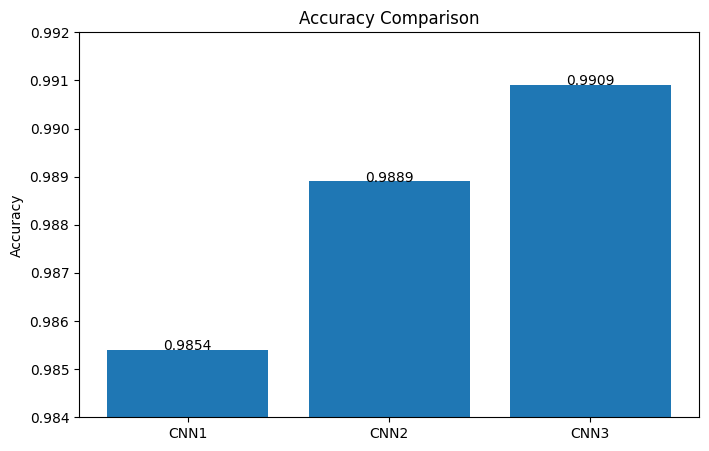

In [ ]:
# Compare classification accuracy across models
plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

plt.ylim(0.984,0.992)

plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.4f}',
        ha='center'
    )

plt.show()

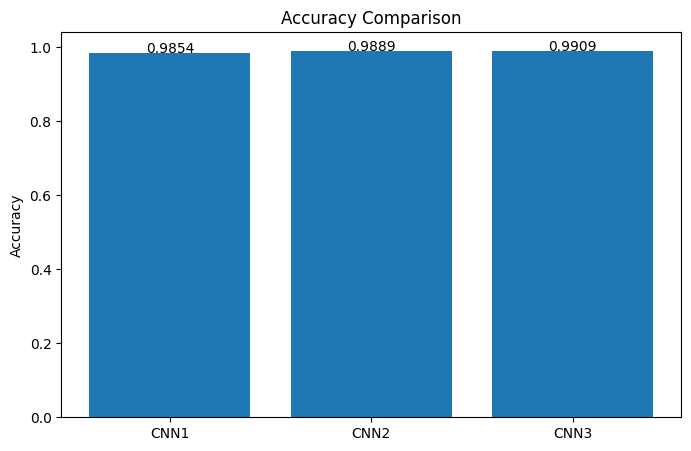

In [ ]:
# Display accuracy comparison bar chart
models = ['CNN1', 'CNN2', 'CNN3']
accuracies = [acc_1, acc_2, acc_3]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.4f}',
        ha='center'
    )

plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()

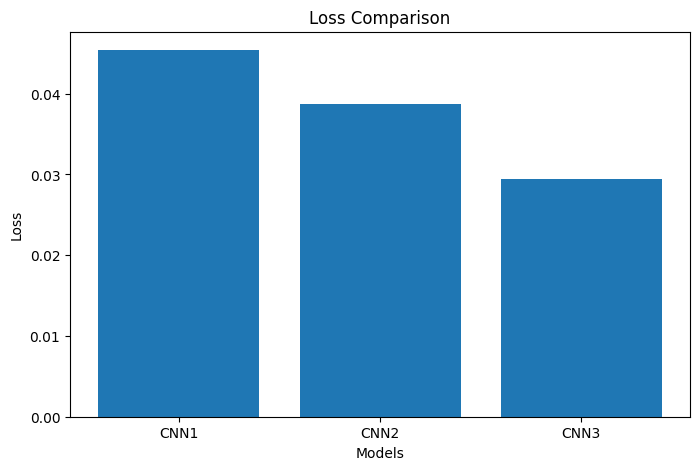

In [ ]:
# Compare loss values across models
losses = [loss_1, loss_2, loss_3]

plt.figure(figsize=(8,5))

plt.bar(models, losses)

plt.title('Loss Comparison')
plt.xlabel('Models')
plt.ylabel('Loss')

plt.show()

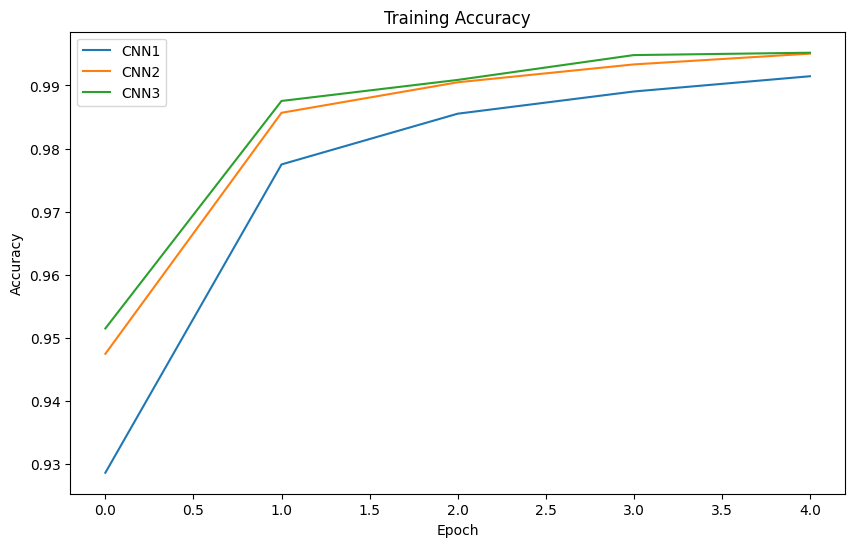

In [ ]:
# Display training accuracy over epochs
plt.figure(figsize=(10,6))

plt.plot(
    history_1.history['accuracy'],
    label='CNN1'
)

plt.plot(
    history_2.history['accuracy'],
    label='CNN2'
)

plt.plot(
    history_3.history['accuracy'],
    label='CNN3'
)

plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

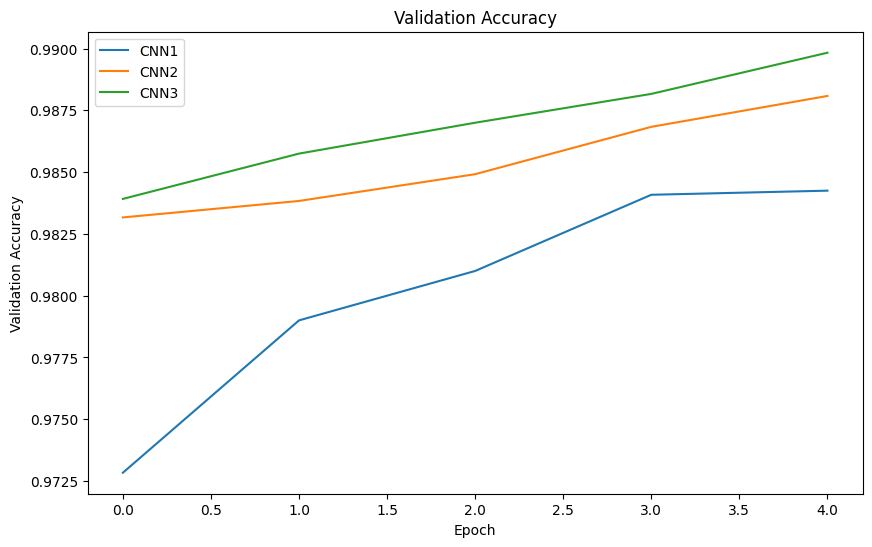

In [ ]:
# Display validation accuracy over epochs
plt.figure(figsize=(10,6))

plt.plot(
    history_1.history['val_accuracy'],
    label='CNN1'
)

plt.plot(
    history_2.history['val_accuracy'],
    label='CNN2'
)

plt.plot(
    history_3.history['val_accuracy'],
    label='CNN3'
)

plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')

plt.legend()

plt.show()

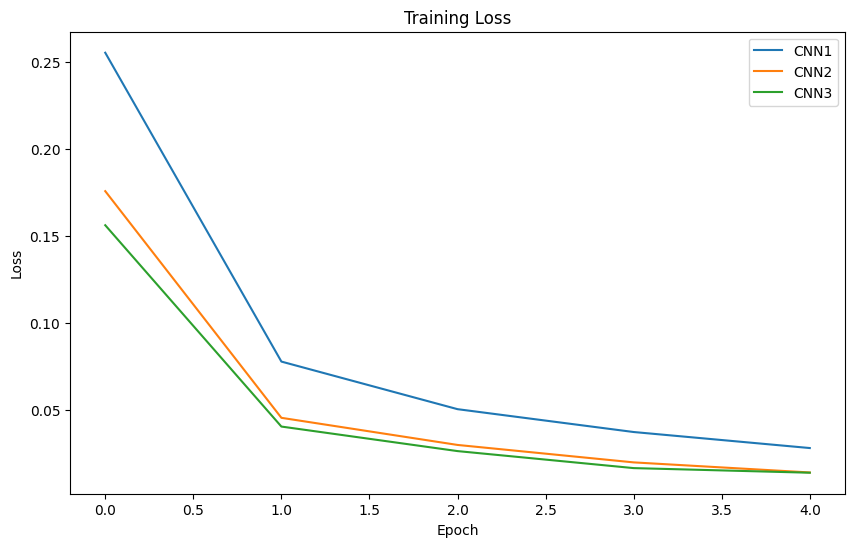

In [ ]:

# Display training loss over epochs
plt.figure(figsize=(10,6))

plt.plot(
    history_1.history['loss'],
    label='CNN1'
)

plt.plot(
    history_2.history['loss'],
    label='CNN2'
)

plt.plot(
    history_3.history['loss'],
    label='CNN3'
)

plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [ ]:
# Display model architecture summaries
model_1.summary()
model_2.summary()
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081,888 (7.94 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 22, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,229,664 (23.76 MB)

 Trainable params: 2,076,554 (7.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,153,110 (15.84 MB)